<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/naive-bayes/Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the financial dataset
df = pd.read_csv('/content/sample_data/financial_data.csv')

In [2]:
# Quick look at the data
df.head()

,Customer_ID,Age,Income,Credit_Score,Investment_Returns,Risk_Level,Customer_Feedback
0,1001,25.0,0.735552,0.127660,11.57,Medium,The app is found.
1,1002,29.0,0.530047,0.157447,7.75,Medium,The service was discontinued.
2,1003,25.0,0.293007,0.421277,11.80,High,Fees are high.
3,1004,41.0,1.000000,0.953191,9.46,Low,Fees are high.
4,1005,25.0,0.934614,0.221277,8.08,High,The app is found.


In [3]:
# Installing necessary libs for Mistral 7B
# - transformers for the model, bitsandbytes for 4-bit quantization
!pip install -q transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.1 MB/s eta 0:00:00


In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

model_id = "mistralai/Mistral-7B-v0.1"

# 4-bit config to make sure Mistral fits on the T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load the tokenizer and model with the quantization config
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Set up a basic text generation pipeline
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Function to prompt Mistral for a quick sentiment score
def get_mistral_score(text):
    prompt = f"Text: {text}\nSentiment (-1, 0, 1):"

    # Generate just enough tokens to get the answer
    res = generator(prompt, max_new_tokens=2, do_sample=False)
    out = res[0]['generated_text'].split("Sentiment (-1, 0, 1):")[-1].strip()

    if "-1" in out: return -1.0
    if "1" in out: return 1.0
    return 0.0

# Run the model on the dataset and check results
print("Mistral is processing...")
df['Sentiment_Score'] = df['Customer_Feedback'].apply(get_mistral_score)

df[['Customer_Feedback', 'Sentiment_Score']].head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Mistral is processing...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting

,Customer_Feedback,Sentiment_Score
0,The app is found.,0.0
1,The service was discontinued.,0.0
2,Fees are high.,-1.0
3,Fees are high.,-1.0
4,The app is found.,0.0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the data
# Using the Mistral sentiment score as a feature for the Risk_Level prediction
X = df[['Age', 'Income', 'Credit_Score', 'Sentiment_Score']]
y = df['Risk_Level']

In [6]:
# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 3. Initialize and train Gaussian Naive Bayes
# Using GaussianNB since our features (Age, Income, etc.) are continuous numbers
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [8]:
# 4. Predict and check results
y_pred = gnb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.42

Classification Report:
              precision    recall  f1-score   support

        High       0.36      0.33      0.35        60
         Low       0.44      0.51      0.48        86
      Medium       0.43      0.37      0.40        54

    accuracy                           0.42       200
   macro avg       0.41      0.41      0.41       200
weighted avg       0.42      0.42      0.42       200



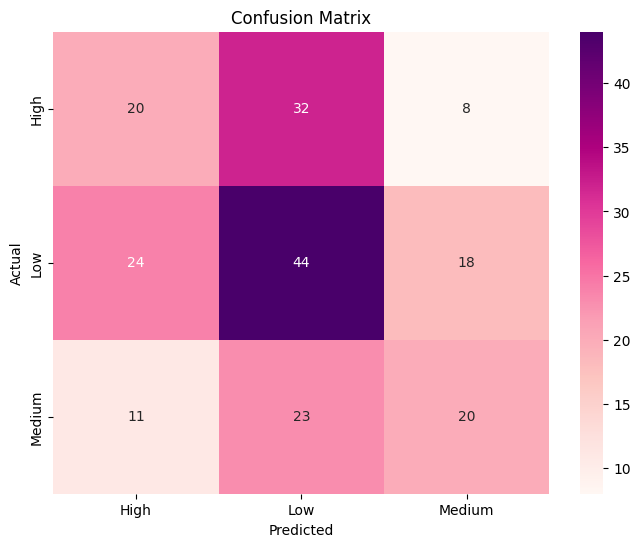

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the matrix to see where the model guessing wrong
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()